# Esercitazione 9

**29 Aprile 2024**

*Gradiente e gradiente coniugato*

In [1]:
from gradient import steep 
import numpy as np
import numpy.linalg as lin
import scipy.linalg as splin
import IPython.display as nb
import matplotlib.pyplot as plt
from curves import *
from numpy.linalg import norm
from displayutils import display_matrix, display_vector
from itertools import takewhile

markdown = lambda str: nb.display(nb.Markdown(str))

In [2]:
def plot_error(args):
    x, err, _, it = args
    plt.semilogy(range(it), err)

In [3]:
def test_convergence(A, methods, b=None, visible=False, itmax=100):
    if visible == True:
        markdown('## Matrix is:\n')
        display_matrix(A, notation=f'A')
    if b is None:
        b = A @ np.ones(len(A))
    plt.title('Convergence comparison between steep methods')
    [plot_error(meth(A, b, itmax=itmax)) for meth in methods.values()]
    plt.legend(methods.keys())

In [4]:
def f(x, A, b):
    x = np.array(x)
    xtax = x.T @ A @ x
    btx = b.T @ x
    return 0.5 * xtax - btx

## Metodo del gradiente (variante discesa ripida)
Generico metodo di discesa in funzione delle varianti alfa e vettore direzione

``` python
def stop_criteria(i, args):
    res, _, _ = args
    return i < itmax and err(res, b) >= toll

def iteration(res, x, p):
    Ap = A @ p
    a = alfa(A, res, p)
    r = res + a*Ap
    return r, x + a*p, p(r)
```

## Esercizio 1
Implementare la funzione **steepestdescent(A,b,x0,itmax,tol)** che implementa il metodo di discesa più ripida del gradiente per risolvere il sistema lineare Ax=b, con A matrice simmetrica e definita positiva. La funzione prende in input:
- A: matrice dei coefficienti
- b: termine noto
- x0: vettore iniziale della stessa dimensione di b
- itmax: iterazioni massime oltre le quali il metodo si ferma
- toll: tolleranza per il criterio di arresto

e restituisce in output:
- il vettore soluzione
- un vettore di tante componenti quanto il numero di iterazioni effettuate, contenente $ \frac{||r^{(k)}||_2} {||b||_2}$ iterazione per iterazione

- un array contenente le soluzioni ad ogni iterazione
- il numero di iterazioni impiegate per calcolare la soluzione con la tolleranza richiesta

Usare come criterio di arresto $ \frac{||r^{(k)}||_2} {||b||_2} < toll$

In [5]:
def steepscent(A, b, itmax=100, toll=1e-10):
    alfa = lambda A, res, p: -res @ p / (A @ p @ p)
    p = lambda res, _, p: -res
    return steep(A, b, alfa, p, itmax=itmax, toll=toll)

## Esercizio 1-Bis
Implementare la funzione **steepestdescent_CL(A,b,x0,itmax,X,Y,Z,tol)** da utilizzare solo nel caso n=2 che visualizza anche le curve di livello e l'iterato x_k.

N.B: f(x) è il funzionale quadratico da minimizzare (f(x)= <Ax,x>-<b,x>) ,
X,Y sono la discretizzazione del piano su cui costruire Z (ottenuta valutando f sui punti della griglia)

In [6]:
def steepestdescent_CL(A, b, X, Y, Z, x0=None, itmax=100, toll=1e-8):
    markdown('## Steep descent Plotting')
    ax = plot_3D_projection(X, Y, Z, f, (A, b))
    plt.title('Plot of quadratic function \n(minum point is solution)')
    plt.show()
    _, _, vec_x, _ = steepscent(A, b, itmax=itmax, toll=toll)
    res = [chached_countor(sol, (X, Y), Z, f, (A, b)) for sol in vec_x]
    plt.title('Plot solutions curves (referring to the quadratic function)\n which points direct the solution')
    plt.show()

## Esercizio 2
Implementare la funzione **conjugate_gradient(A,b,x0,itmax,tol)** che implementa il metodo del gradiente coniugato per risolvere il sistema lineare Ax=b, con A matrice simmetrica e definita positiva. La funzione prende in input:
- A: matrice dei coefficienti
- b: termine noto
- x0: vettore iniziale della stessa dimensione di b
- itmax: iterazioni massime oltre le quali il metodo si ferma
- toll: tolleranza per il criterio di arresto

e restituisce in output:
- il vettore soluzione
- un vettore di tante componenti quanto il numero di iterazioni effettuate, contenente $ \frac{||r^{(k)}||_2} {||b||_2}$ iterazione per iterazione
- un array contenente le soluzioni ad ogni iterazione
- il numero di iterazioni impiegate per calcolare la soluzione con la tolleranza richiesta

Usare come criterio di arresto $ \frac{||r^{(k)}||_2} {||b||_2} < toll$

In [7]:
def conjugate_gradient(A, b, itmax=100, toll=1e-10):
    alfa = lambda A, res, p: res @ res / (A @ p @ p)
    def p(nres, res, p): 
        gamma = nres @ nres / (res @ res)
        return -nres + (gamma * p)
    return steep(A, b, alfa, p, itmax=itmax, toll=toll)

## Esercizio 2-Bis
Implementare la funzione **conjugate_gradient_CL(A,b,x0,itmax,X,Y,Z,tol)** da utilizzare solo nel caso n=2 che visualizza anche le curve di livello e l'iterato x_k

In [8]:
def conjugate_gradient_CL(A, b, X, Y, Z, x0=None, itmax=100, toll=1e-8):
    markdown('## Conjugate Gradient Plotting')
    ax = plot_3D_projection(X, Y, Z, f, (A, b))
    plt.title('Plot of quadratic function \n(minum point is solution)')
    plt.show()
    _, _, vec_x, _ = conjugate_gradient(A, b, itmax=itmax, toll=toll)
    res = [chached_countor(sol, (X, Y), Z, f, (A, b)) for sol in vec_x]
    plt.title('Plot solutions curves (referring to the quadratic function)\n which points direct the solution')
    plt.show()

## Test didattici per il caso n=2, visualizzando le curve di livello

Risolvere il sistema lineare Ax=b, dove A=np.array([[8,4],[4,3]]) e b=np.array([8,10]), utilizzando
il metodo del gradiente e del gradiente coniugato con la visualizzazione grafica delle curve di livello e della soluzione ad ogni iterazione. Si selezioni l'iterato iniziale x0=[0,0], itmax=200
tol=1e-10. Si confrontino le iterazioni effettuate da ciascuno dei due metodi e si visualizzi  $ \frac{||r^{(k)}||_2} {||b||_2}$ ad ogni iterazione.

## Steep descent Plotting

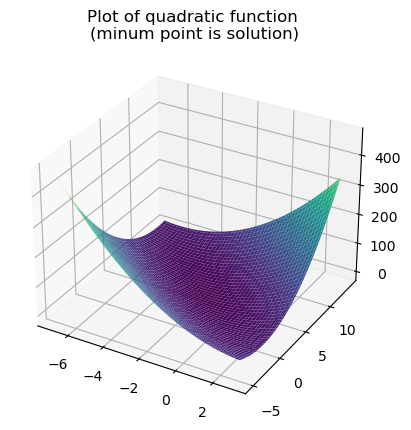

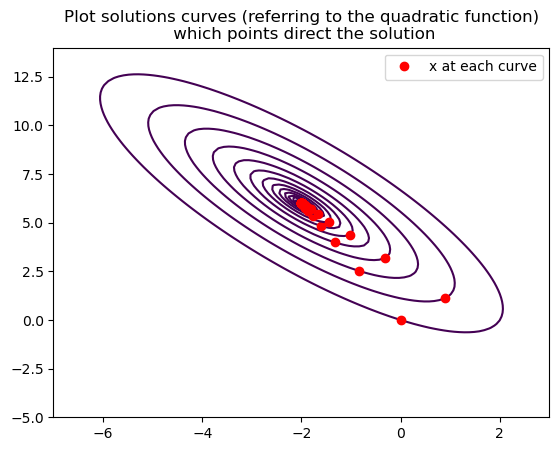

## Conjugate Gradient Plotting

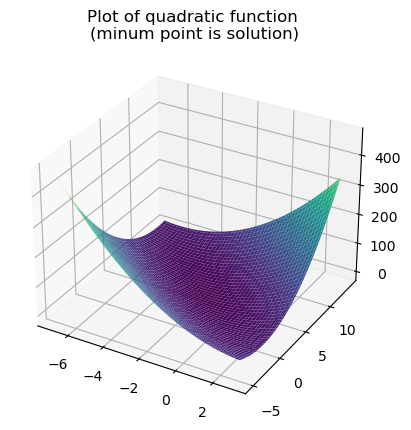

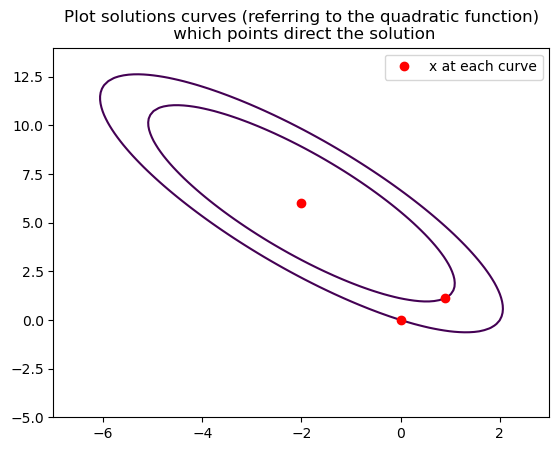

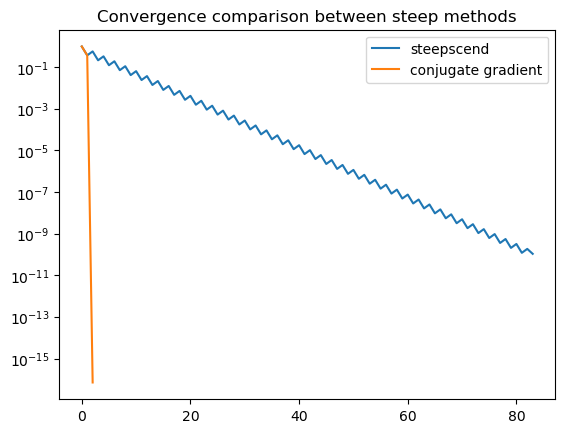

In [9]:
x = np.linspace(-7.0, 3.0, 100)
y = np.linspace(-5.0, 14.0, 100)

A = np.array([[8, 4], [4, 3]])
b = np.array([8, 10])

X, Y, Z = create_mesh(x, y, f, (A, b))

steepestdescent_CL(A, b, X, Y, Z)
conjugate_gradient_CL(A, b, X, Y, Z)
test_convergence(A, methods={'steepscend':steepscent, 'conjugate gradient': conjugate_gradient}, b=b)

## Esercizio 3
Scrivere una funzione creaPoisson(n) che preso in input l'ordine della matrice quadrata di Poisson la costruzione secondo la seguente formula:
$$A =
\left [
\begin{array}{ccccccccccc}
4 & -1 & 0 & -1 &0 &0 & 0& 0& \cdots &   0 & 0\\
-1 & 4 & -1 & 0  &-1 &0 & 0& 0& \cdots &   0 & 0\\
0 & -1 & 4 & -1  &0 &-1 & 0& 0& \cdots &   0 & 0 \\
-1 & 0 & -1 & 4  &-1 &0  & -1 & 0& \cdots &   0 & 0\\
0 & -1 & 0 & -1  & 4 &-1 & 0 & -1& \cdots &   0 & 0\\
0 & 0 & -1 & 0  & -1 &4 & -1 & 0&  -1 & 0 & 0 \\
0 & 0 & 0 & \ddots  & 0 &\ddots & \ddots & \ddots& \ddots & \ddots & 0\\
0 & 0 & 0 & 0  & -1 &0  & -1 & 4& -1 &   0& -1\\
\end{array}
 \right ], \qquad
$$

- Risolvere il sistema lineare Ax=b con matrice dei coefficienti A di Poisson con ordine che va da 10 a 100 con step 2,  e termine noto b scelto in maniera tale che il sistema abbia soluzione il vettore x con tutte le componenti  uguali ad 1, utilizzando  il metodo iterativo del gradiente e del gradiente coniugato  

In [10]:
def creaPoisson(n):
    A = np.identity(n) * 4
    for i in range(1,4,2):
        A -= np.eye(n, k=-i) + np.eye(n, k=i) 
    return A

In [11]:
def error(args):
    x, r, _, it = args
    err = norm(x-1)/norm(x)
    return err

def test_error(A, B, methods):
    n = len(A)
    plt.title('Relative erro of a poisson matrix, using gradient methods')
    y = [[error(meth(A[i], B[i])) for meth in methods.values()] for i in range(n)]
    plt.semilogy(range(n), y)
    plt.legend(methods.keys())

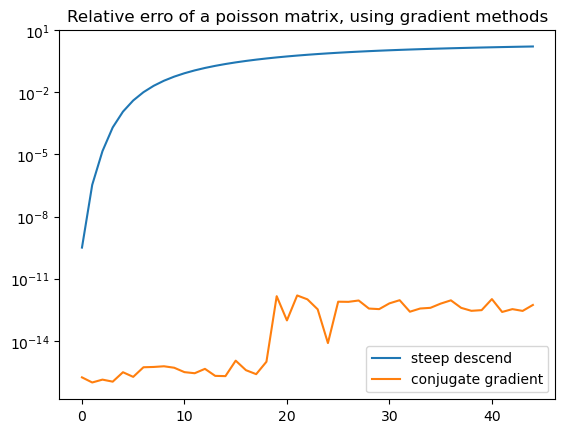

In [12]:
n = np.arange(10, 100, 2)

A = [creaPoisson(i) for i in n]
B = [creaPoisson(i) @ np.ones(i) for i in n]
methods={'steep descend':steepscent, 'conjugate gradient': conjugate_gradient}
test_error(A, B, methods)

## Esercizio 4
Consideriamo il sistema lineare Ax=b  dov A è  la matrice di Hilbert di dimensione 5, costruita usando la funzione hilbert(n) di scipy.linalg (A=scipy.linalg.hilbert(5)) in modo tale che la soluzione esatta sia $x = (1, 1, . . . , 1)^T$ .
Risolvere il sistema lineare usando sia il metodi del gradiente che il metodo del gradiente coniugato e confrontarne gli errori ad ogni iterazione.

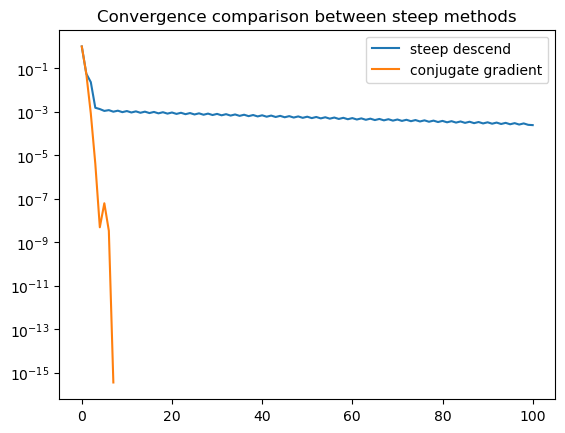

In [151]:
n = 5
A = splin.hilbert(n)
b = A @ np.ones(n)
methods={'steep descend':steepscent, 'conjugate gradient': conjugate_gradient}
test_convergence(A, methods, b=b)test_convergence(A, methods={'steepscend':steepscent, 'conjugate gradient': conjugate_gradient}


## Esercizio 5
Importare il file creaG ed utilizzare le funzioni sottospecificate per creare, scelto $n$,  una matrice D di ordine $m=(n-2)^2$

*import creaG*

*G = creaG.numgrid(n)*

*D = creaG.delsq(G).todense().getA()*

Risolvere il sistema lineare Dx=b, con matrice G di ordine m=16 ed ordine m=400, (scegliere n in maniera opportuna), usando i metodi del gradiente e del gradiente coniugato. Confrontare gli errori su uno stesso grafico e giustifcare i risultati alla luce del risultato teorico della maggiorazione dell'errore per entrambi i metodi

In [15]:
from creaG import *

def test_g(n):
    m = (n - 2)**2
    G = numgrid(n)
    D = delsq(G).todense().getA()
    markdown(f'## G at order {n}')
    methods={'steep descend':steepscent, 'conjugate gradient': conjugate_gradient}
    test_convergence(D, methods, itmax=2000)
    plt.show()

## G at order 6

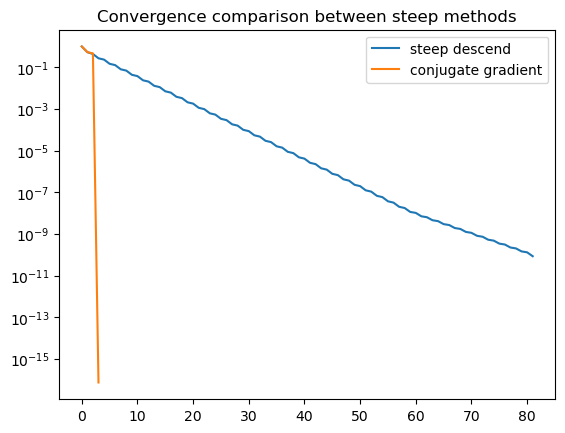

## G at order 22

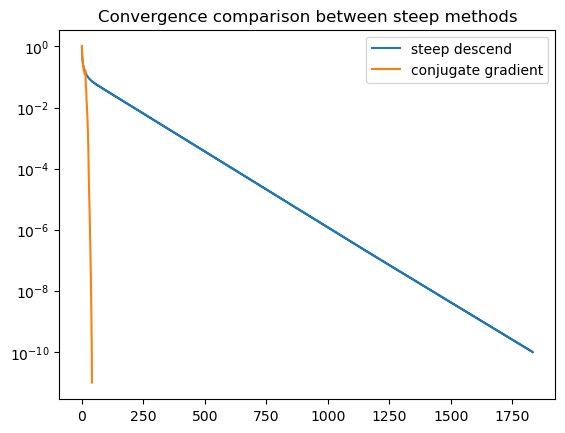

In [16]:
test_g(6)
test_g(22)